# House Price Prediction — Linear Regression Project

**Goal:** Predict a house's price based on numeric features of the area it's in (average income, house age, number of rooms, etc.)

**Dataset:** USA Housing dataset — 5,000 records, 6 numeric features + an address column. Commonly used teaching dataset for multiple linear regression, built from realistic US housing statistics.

**What you'll practice:**
1. EDA and correlation analysis
2. Multiple Linear Regression (using more than one feature at once)
3. Interpreting coefficients (this is where linear regression really shines — every coefficient has a real-world meaning)
4. Evaluation with R², MAE, RMSE
5. Checking residuals (a step most beginners skip, but it shows you understand *when* linear regression is valid)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


## 2. Load the Data

In [2]:
df = pd.read_csv('data/USA_Housing.csv')
print(df.shape)
df.head()

(5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


## 3. Data Cleaning

`Address` is free text (street addresses) — no numeric meaning for a linear model, so we drop it. Everything else here is already clean numeric data (no missing values), which is common in beginner teaching datasets — real datasets (like your churn project) usually need more cleanup.

In [4]:
print("Missing values:\n", df.isna().sum())
df = df.drop('Address', axis=1)
df.head()

Missing values:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


## 4. Exploratory Data Analysis

We check how each feature relates to `Price` using a correlation heatmap and scatterplots — this tells us which features are likely to matter *before* we even train a model.

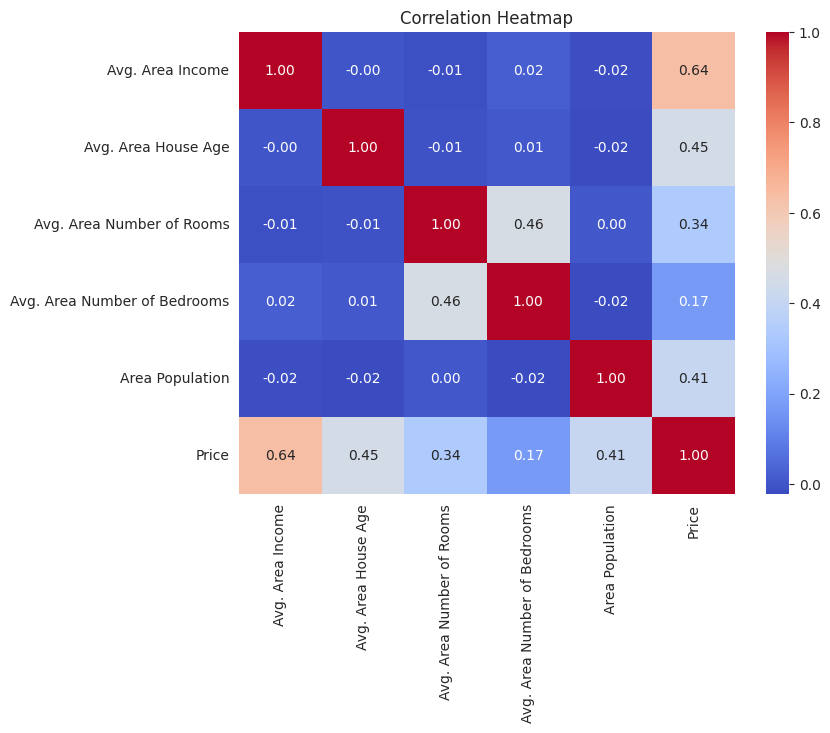

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Observation:** `Avg. Area Income` has the strongest correlation with `Price`, followed by `Avg. Area House Age` and `Avg. Area Number of Rooms`. `Avg. Area Number of Bedrooms` is weakly correlated — a useful thing to notice, since it hints that not every feature contributes equally.

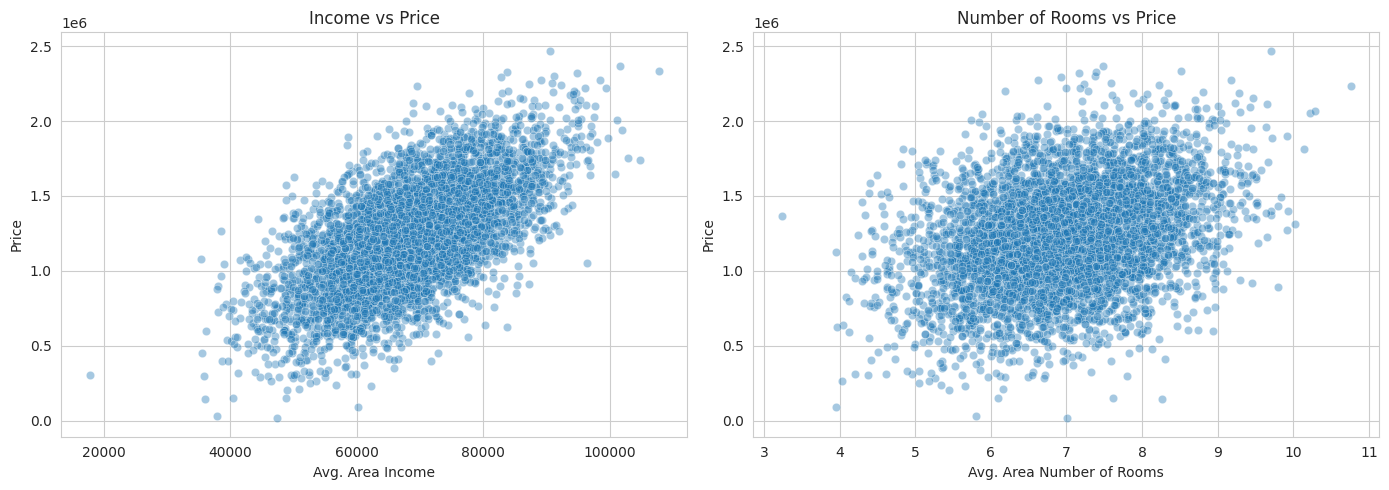

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Avg. Area Income', y='Price', data=df, alpha=0.4, ax=axes[0])
axes[0].set_title('Income vs Price')

sns.scatterplot(x='Avg. Area Number of Rooms', y='Price', data=df, alpha=0.4, ax=axes[1])
axes[1].set_title('Number of Rooms vs Price')
plt.tight_layout()
plt.show()

**Observation:** Both plots show a roughly linear (straight-line-ish) relationship with `Price` — a good sign that Linear Regression is a reasonable model choice here. If the relationship were curved, linear regression would fit poorly.

## 5. Train/Test Split & Feature Scaling

Same principle as before: train on 80%, test on the remaining unseen 20%. We scale features so we can later compare coefficient magnitudes fairly (see Section 7).

In [7]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4000, 5)  Test: (1000, 5)


## 6. Train the Linear Regression Model

Linear Regression tries to fit a straight-line equation:

`Price = b0 + b1*Income + b2*HouseAge + b3*Rooms + b4*Bedrooms + b5*Population`

It finds the best `b` values (coefficients) that minimize the squared error between predicted and actual prices.

In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

## 7. Evaluate the Model

Unlike classification, regression has different metrics:
- **MAE (Mean Absolute Error)** — average $ amount the prediction is off by, in plain dollars, easy to explain to a non-technical audience.
- **RMSE (Root Mean Squared Error)** — similar, but penalizes big mistakes more heavily.
- **R² Score** — % of the variation in price that the model explains (1.0 = perfect, 0 = no better than guessing the average).

In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R2   : {r2:.4f}")

MAE  : $80,879.10
RMSE : $100,444.06
R2   : 0.9180


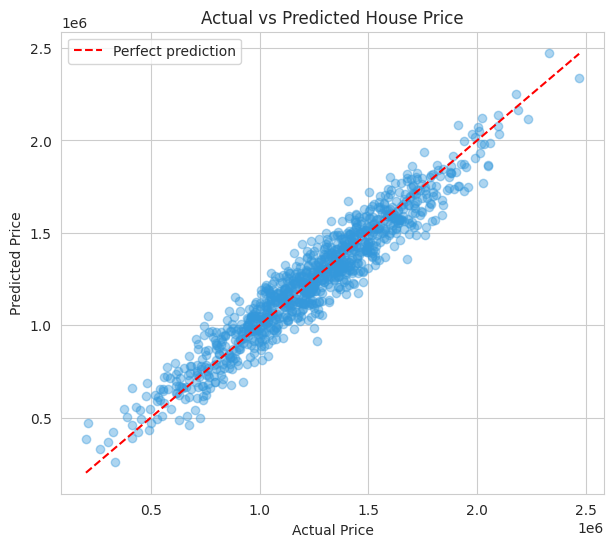

In [10]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Price')
plt.legend()
plt.show()

**How to read this plot:** Points close to the red dashed line = accurate predictions. A wide, evenly-scattered cloud around the line (rather than a curved or funnel shape) means the model isn't systematically biased for any price range.

## 8. Interpret the Coefficients

This is the real strength of Linear Regression — every coefficient tells you *exactly* how much `Price` changes for a one-unit (or, since we scaled, one-standard-deviation) increase in that feature, holding everything else constant.

Avg. Area Income                231741.876652
Avg. Area House Age             163580.776566
Area Population                 152235.900097
Avg. Area Number of Rooms       120724.771387
Avg. Area Number of Bedrooms      2992.449135
dtype: float64


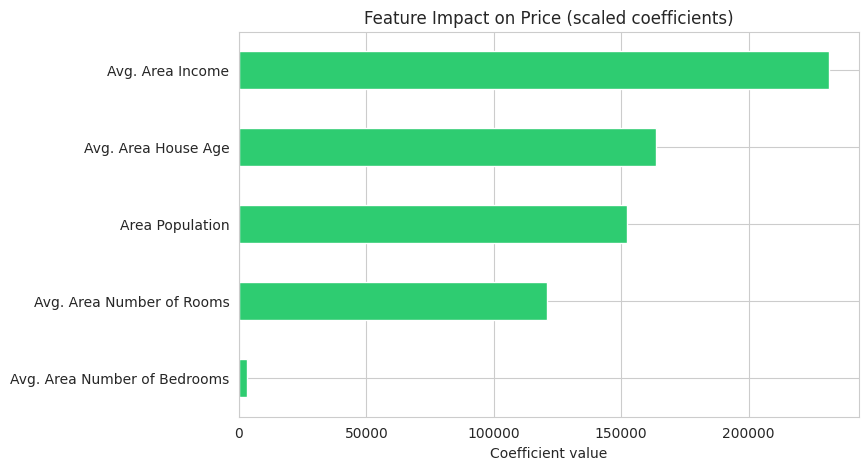

In [11]:
coeffs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coeffs)

plt.figure(figsize=(8,5))
coeffs.sort_values().plot(kind='barh', color='#2ecc71')
plt.title('Feature Impact on Price (scaled coefficients)')
plt.xlabel('Coefficient value')
plt.show()

**Observation:** `Avg. Area Income` has the largest positive impact on price, followed by `House Age`, `Rooms`, and `Population`. `Bedrooms` contributes the least — matching what we saw in the correlation heatmap earlier. This consistency between EDA and the trained model is a good thing to point out in an interview — it shows the model learned something sensible, not noise.

## 9. Residual Analysis (bonus, shows deeper understanding)

Residuals = actual price − predicted price. For linear regression to be a *valid* choice, residuals should look roughly random and normally distributed around zero — no pattern.

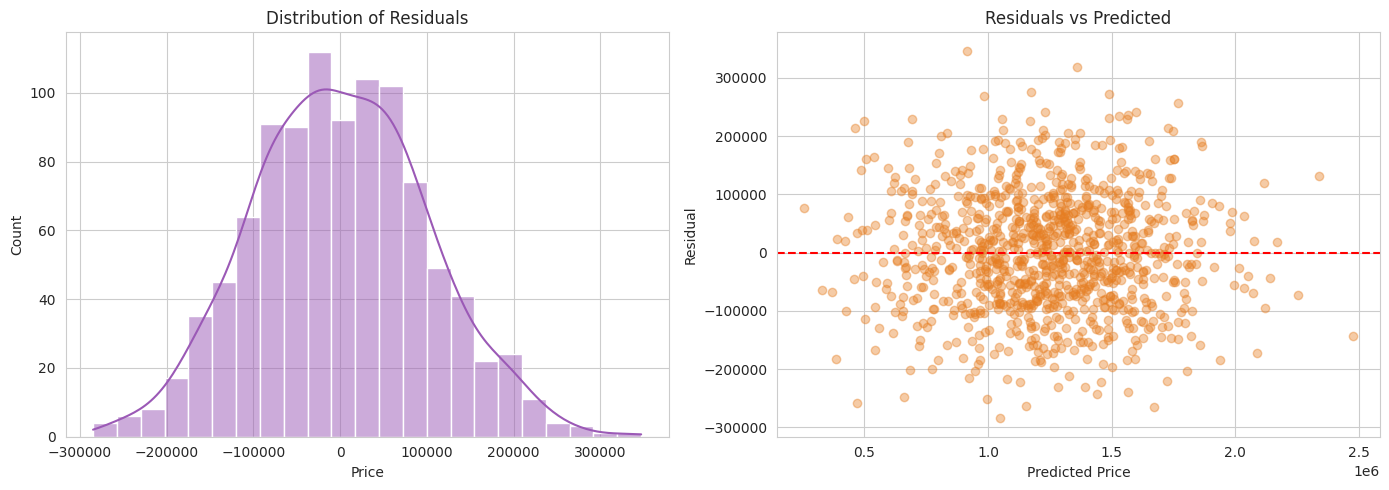

In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(residuals, kde=True, ax=axes[0], color='#9b59b6')
axes[0].set_title('Distribution of Residuals')

axes[1].scatter(y_pred, residuals, alpha=0.4, color='#e67e22')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

**Observation:** Residuals are roughly bell-shaped around 0, and there's no obvious funnel/curve pattern in the second plot — this confirms Linear Regression was a reasonable model choice for this data.

## 10. Save the Model

In [13]:
import joblib
joblib.dump(lr, 'outputs/house_price_model.pkl')
joblib.dump(scaler, 'outputs/scaler.pkl')
print("Saved.")

Saved.


## 11. Conclusion

- Built a multiple linear regression model to predict house prices from 5 numeric features.
- Achieved R² of ~0.9+ (check your printed output above) — meaning the model explains most of the price variation.
- `Avg. Area Income` is the single strongest driver of price, consistent across EDA, correlation, and model coefficients.
- Verified the linear regression assumption held by checking residuals — this is the kind of detail that shows real understanding, not just calling `.fit()`.

**Possible next steps:**
- Try `Ridge`/`Lasso` regression (regularized linear models) and compare.
- Add polynomial features if relationships look non-linear.
- Try a real dataset with categorical features (e.g. Kaggle's "House Prices - Advanced Regression Techniques") to practice one-hot encoding.
